# 模块 7：控制仲裁（`/control_mux`）调用示例

对应 `design/函数接口.md` 模块 7，演示两个部分：

1. `select_channel(state)` —— 状态 → 放行通道仲裁；
2. `ControlMux` —— 事件转发（收到即转、每路只留最新）。

本 notebook 包含 **4 个场景**：

| 场景 | 内容 |
|---|---|
| 1 | 仲裁规则表：三态 + 未知值回退 |
| 2 | 事件转发时序：状态切换 + 双路指令，谁被放行 / 丢弃 |
| 3 | 每路只留最新一条（`queue_size=1`） |
| 4 | 开发 / 上机阶段开关演示 |

> 范围说明：本模块只做**纯逻辑**（无 ROS 依赖），`PositionTarget` 按不透明对象处理；
> `rospy` 节点壳（订阅 / 发布 / 日志）在集成阶段封装。

In [1]:
import os
import sys
import logging
import importlib
import warnings

# 确保可 import 同目录下的 control_mux / config
sys.path.insert(0, os.path.abspath('.'))

%matplotlib inline
import matplotlib.pyplot as plt

import control_mux as cm

logging.basicConfig(level=logging.INFO, format='%(message)s')
print('control_mux.STAGE =', cm.STAGE, '| ONBOARD =', cm.ONBOARD)

control_mux.STAGE = dev | ONBOARD = False


## 0. 辅助

- `cmd(name)`：构造一条「指令」占位对象（mux 不解析内容，仅原样转发）；
- 配色沿用 `design/函数接口.md` 模块着色：**雷达蓝** `/ctrl/radar`、**视觉紫** `/ctrl/visual`。

In [6]:
C_RADAR = '#1565c0'   # 雷达蓝（与 design 着色一致）
C_VISUAL = '#7b1fa2'  # 视觉紫
C_DROP = '#9e9e9e'    # 丢弃灰
CH_COLOR = {cm.CHANNEL_RADAR: C_RADAR, cm.CHANNEL_VISUAL: C_VISUAL}

# 中文字体（环境自带 Noto Sans CJK），保证标题/图例正常显示
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


def cmd(name):
    """构造一条「指令」占位对象（mux 把指令视为不透明对象）。"""
    return {'name': name}

## 1. 仲裁规则表

`select_channel` 按 `/state` 值选放行通道：`RADAR_GUIDE`→雷达、`VISUAL_LOCK`→视觉，
**其他值（含 `SEARCH/RTH`、空串、未知值）一律回退雷达**。

In [3]:
states = ['RADAR_GUIDE', 'VISUAL_LOCK', 'SEARCH/RTH', '', 'WHATEVER']
print('%-16s -> %s' % ('/state 值', '放行通道'))
print('-' * 40)
for s in states:
    print('%-16r -> %s' % (s, cm.select_channel(s)))

/state 值         -> 放行通道
----------------------------------------
'RADAR_GUIDE'    -> /ctrl/radar
'VISUAL_LOCK'    -> /ctrl/visual
'SEARCH/RTH'     -> /ctrl/radar
''               -> /ctrl/radar
'WHATEVER'       -> /ctrl/radar


## 2. 事件转发时序

模拟一段事件流：`/ctrl/radar`、`/ctrl/visual` 两路都在发指令，`/state` 在中途切换。
mux **收到即判**：当前放行通道的指令被转发，另一路被丢弃。


In [4]:
mux = cm.ControlMux()

# (事件类型, ...)：('state', 状态) / ('cmd', 通道, 指令名)
events = [
    ('cmd',   cm.CHANNEL_RADAR,  'R1'),
    ('cmd',   cm.CHANNEL_VISUAL, 'V1'),   # 当前雷达态 → 视觉指令被丢弃
    ('state', 'VISUAL_LOCK'),             # 切到视觉
    ('cmd',   cm.CHANNEL_RADAR,  'R2'),   # 视觉态 → 雷达指令被丢弃
    ('cmd',   cm.CHANNEL_VISUAL, 'V2'),
    ('state', 'RADAR_GUIDE'),             # 切回雷达
    ('cmd',   cm.CHANNEL_VISUAL, 'V3'),   # 雷达态 → 视觉指令被丢弃
    ('cmd',   cm.CHANNEL_RADAR,  'R3'),
]

rows = []
for ev in events:
    if ev[0] == 'state':
        mux.on_state(ev[1])
        rows.append((mux.state, 'state', 'state -> %s' % ev[1]))
    else:
        _, ch, name = ev
        out = mux.on_command(ch, cmd(name))
        rows.append((mux.state, name, '转发' if out is not None else '丢弃'))

print('%-14s %-7s %s' % ('当前状态', '指令', '结果'))
print('-' * 34)
for st, name, res in rows:
    print('%-14s %-7s %s' % (st, name, res))

当前状态           指令      结果
----------------------------------
RADAR_GUIDE    R1      转发
RADAR_GUIDE    V1      丢弃
VISUAL_LOCK    state   state -> VISUAL_LOCK
VISUAL_LOCK    R2      丢弃
VISUAL_LOCK    V2      转发
RADAR_GUIDE    state   state -> RADAR_GUIDE
RADAR_GUIDE    V3      丢弃
RADAR_GUIDE    R3      转发


[mux] state -> VISUAL_LOCK
[mux] state -> RADAR_GUIDE


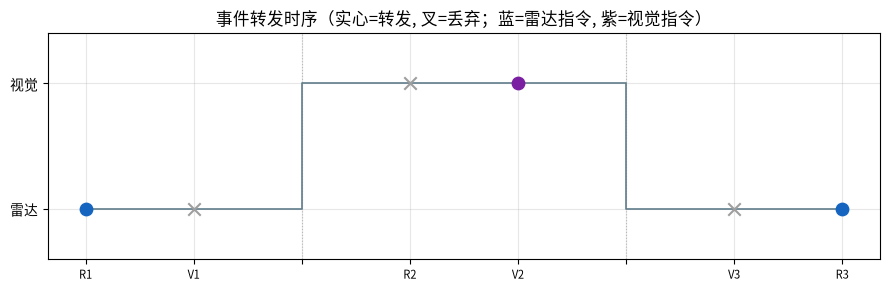

In [7]:
# 时序图：状态阶梯 + 指令放行/丢弃标记
ymap = {'RADAR_GUIDE': 0, 'VISUAL_LOCK': 1, 'SEARCH/RTH': 0}
xs = list(range(len(rows)))
ys = [ymap.get(st, 0) for st, _, _ in rows]

fig, ax = plt.subplots(figsize=(9, 3.0))
ax.step(xs, ys, where='post', color='#607d8b', lw=1.2,
        label='当前通道（0=雷达, 1=视觉）')

for i, (st, name, res) in enumerate(rows):
    if name == 'state':
        ax.axvline(i, color='#bdbdbd', ls=':', lw=0.8, zorder=1)
        continue
    ch = cm.CHANNEL_VISUAL if name.startswith('V') else cm.CHANNEL_RADAR
    fwd = res == '转发'
    ax.scatter(i, ymap.get(st, 0),
               color=CH_COLOR[ch] if fwd else C_DROP,
               marker='o' if fwd else 'x', s=80, zorder=3)

ax.set_xticks(xs)
ax.set_xticklabels([n if n != 'state' else '' for _, n, _ in rows], fontsize=8)
ax.set_yticks([0, 1])
ax.set_yticklabels(['雷达', '视觉'])
ax.set_ylim(-0.4, 1.4)
ax.set_title('事件转发时序（实心=转发, 叉=丢弃；蓝=雷达指令, 紫=视觉指令）')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 每路只留最新一条

`queue_size=1` 语义：每条通道只缓存**最新**一条指令。即使某路指令被丢弃，
它仍会刷新该路缓存；`latest(channel)` 可取回。

In [8]:
mux = cm.ControlMux()
mux.on_command(cm.CHANNEL_RADAR, cmd('R1'))
mux.on_command(cm.CHANNEL_RADAR, cmd('R2'))
mux.on_command(cm.CHANNEL_RADAR, cmd('R3'))
mux.on_command(cm.CHANNEL_VISUAL, cmd('V1'))   # 雷达态下被丢弃，但仍缓存为最新

print('雷达路最新（应为 R3）：', mux.latest(cm.CHANNEL_RADAR))
print('视觉路最新（应为 V1）：', mux.latest(cm.CHANNEL_VISUAL))

雷达路最新（应为 R3）： {'name': 'R3'}
视觉路最新（应为 V1）： {'name': 'V1'}


## 4. 开发 / 上机阶段开关

由环境变量 `UAV_STAGE` 控制（见 `code/config.py`）：

- `dev`（默认）：非法输入直接抛 `ValueError`，问题尽早暴露；
- `onboard`：非法输入发 `RuntimeWarning` 并走默认分支（不崩溃）。

In [10]:
import config

# --- dev（默认）：未知通道直接抛错 ---
os.environ.pop('UAV_STAGE', None)
importlib.reload(config)
importlib.reload(cm)
print('当前 STAGE =', cm.STAGE, '| ONBOARD =', cm.ONBOARD)
try:
    cm.ControlMux().on_command('/ctrl/bad', cmd('X'))
except ValueError as e:
    print('[dev] 抛错:', e)

# --- onboard：改为告警 + 丢弃（阶段在 config 导入时读取，故需一并重载 config）---
os.environ['UAV_STAGE'] = 'onboard'
importlib.reload(config)
importlib.reload(cm)
print('\n重载后 STAGE =', cm.STAGE, '| ONBOARD =', cm.ONBOARD)
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter('always')
    out = cm.ControlMux().on_command('/ctrl/bad', cmd('X'))
print('onboard 下 on_command 返回:', out, '| 告警数:', len(w))
print('告警内容:', str(w[0].message) if w else None)

# 还原环境，避免影响后续运行
os.environ.pop('UAV_STAGE', None)
importlib.reload(config)
importlib.reload(cm)
print('\n已还原 STAGE =', cm.STAGE)

当前 STAGE = dev | ONBOARD = False
[dev] 抛错: [control_mux] on_command: 未知通道 '/ctrl/bad'

重载后 STAGE = onboard | ONBOARD = True
onboard 下 on_command 返回: None | 告警数: 1
告警内容: [control_mux] on_command: 未知通道 '/ctrl/bad'；上机阶段按默认值处理

已还原 STAGE = dev
